# 1.1 Unidad espacial de análisis

La unidad espacial de análisis fue definida previamente en el cuaderno de inferencia topológica. En esta etapa se reutilizan los nodos HDBSCAN, corredores topológicos y/o regiones costeras como unidades base para construir las series de máximos anuales, excedentes anuales y periodos de retorno.

In [ ]:
# librerias
import pandas as pd
import numpy as np
from scipy import stats

In [ ]:
# Esto se realizó en inferencia topologica
# Dataset base recortado al Pacífico
df = pd.read_excel("huracanes_pacifico_recortado.xlsx")

# Nodos topológicos generados previamente
nodos_modelo = pd.read_csv("nodos.csv")

# Aristas
grafo_aristas = pd.read_csv("grafo_aristas.csv")

# Dataset de transiciones
dataset_transiciones = pd.read_excel("ground_truth_evaluacion_topologica.xlsx")

## 1.2 Seleccion de variables extremas
1. viento extremo = max_wind_kt
2. deficit presion = 1013.25 - min_pressure_mb

Como las distribuciones de máximos trabajan con valores altos, convertimos la presión mínima en déficit de presión tal que:

deficit presion = presión atmosférica estándar - presión mínima observada

In [ ]:
# Asegurar formato de fecha ya que algunas veces la fecha en python se lee como texto y no queremos eso
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

# Crear año y mes
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month

# Columnas principales
columnas_base = [
    "storm_id",
    "name",
    "datetime",
    "year",
    "month",
    "lat",
    "lon",
    "max_wind_kt",
    "min_pressure_mb"
]

display(df[columnas_base].head())
# Presión atmosférica estandar a nivel del mar
presion_referencia = 1013.25

# Deficit de presión
df["deficit_presion_mb"] = presion_referencia - df["min_pressure_mb"]

# Cuando min_pressure_mb es nula, deficit_presion_mb también queda como valor nulo
display(df[[
    "storm_id",
    "name",
    "datetime",
    "max_wind_kt",
    "min_pressure_mb",
    "deficit_presion_mb"
]].head(20))
# eliminar valores nulos
datos_viento = df.dropna(
    subset=["datetime", "year", "max_wind_kt"]
).copy()

# resumen estadistico
datos_presion = df.dropna(
    subset=["datetime", "year", "min_pressure_mb", "deficit_presion_mb"]
).copy()

resumen_extremos = pd.DataFrame({
    "variable": [
        "max_wind_kt",
        "min_pressure_mb",
        "deficit_presion_mb"
    ],
    "descripcion": [
        "Viento máximo sostenido en nudos",
        "Presión mínima central en milibares",
        "Déficit de presión respecto a 1013.25 mb"
    ],
    "registros_validos": [
        df["max_wind_kt"].notna().sum(),
        df["min_pressure_mb"].notna().sum(),
        df["deficit_presion_mb"].notna().sum()
    ],
    "media": [
        df["max_wind_kt"].mean(),
        df["min_pressure_mb"].mean(),
        df["deficit_presion_mb"].mean()
    ],
    "minimo": [
        df["max_wind_kt"].min(),
        df["min_pressure_mb"].min(),
        df["deficit_presion_mb"].min()
    ],
    "maximo": [
        df["max_wind_kt"].max(),
        df["min_pressure_mb"].max(),
        df["deficit_presion_mb"].max()
    ]
})

display(resumen_extremos)
variables_extremas = {
    "viento_maximo_anual": {
        "columna_base": "max_wind_kt",
        "tipo_extremo": "maximo",
        "unidad": "kt",
        "descripcion": "Máximo anual del viento máximo sostenido"
    },
    "deficit_presion_maximo_anual": {
        "columna_base": "deficit_presion_mb",
        "tipo_extremo": "maximo",
        "unidad": "mb",
        "descripcion": "Máximo anual del déficit de presión"
    }
}

variables_extremas

,storm_id,name,datetime,year,month,lat,lon,max_wind_kt,min_pressure_mb
0,CP032013,THREE,2013-08-09 06:00:00,2013,8,11.0,-116.2,20,1008.0
1,CP032013,THREE,2013-08-09 12:00:00,2013,8,11.2,-116.2,20,1007.0
2,CP032013,THREE,2013-08-09 18:00:00,2013,8,11.4,-116.8,20,1007.0
3,CP032013,THREE,2013-08-10 00:00:00,2013,8,11.6,-117.4,20,1007.0
4,CP032013,THREE,2013-08-10 06:00:00,2013,8,12.0,-118.1,25,1008.0


,storm_id,name,datetime,max_wind_kt,min_pressure_mb,deficit_presion_mb
0,CP032013,THREE,2013-08-09 06:00:00,20,1008.0,5.25
1,CP032013,THREE,2013-08-09 12:00:00,20,1007.0,6.25
2,CP032013,THREE,2013-08-09 18:00:00,20,1007.0,6.25
3,CP032013,THREE,2013-08-10 00:00:00,20,1007.0,6.25
4,CP032013,THREE,2013-08-10 06:00:00,25,1008.0,5.25
5,CP032013,THREE,2013-08-10 12:00:00,25,1008.0,5.25
6,CP032013,THREE,2013-08-10 18:00:00,25,1008.0,5.25
7,CP032013,THREE,2013-08-11 00:00:00,25,1008.0,5.25
8,CP032013,THREE,2013-08-11 06:00:00,25,1008.0,5.25
9,CP032013,THREE,2013-08-11 12:00:00,25,1008.0,5.25


,variable,descripcion,registros_validos,media,minimo,maximo
0,max_wind_kt,Viento máximo sostenido en nudos,21233,48.805915,10.00,185.00
1,min_pressure_mb,Presión mínima central en milibares,12558,995.153846,872.00,1015.00
2,deficit_presion_mb,Déficit de presión respecto a 1013.25 mb,12558,18.096154,-1.75,141.25


{'viento_maximo_anual': {'columna_base': 'max_wind_kt',
  'tipo_extremo': 'maximo',
  'unidad': 'kt',
  'descripcion': 'Máximo anual del viento máximo sostenido'},
 'deficit_presion_maximo_anual': {'columna_base': 'deficit_presion_mb',
  'tipo_extremo': 'maximo',
  'unidad': 'mb',
  'descripcion': 'Máximo anual del déficit de presión'}}

## 1.3. Construccion de la serie de maximos anuales

In [ ]:
# Definir unidades regionales
posibles_columnas_region = [
    "node_id",
    "nodo_actual",
    "region_id",
    "cell_id",
    "cluster_hdbscan"
]

region_col = None

for col in posibles_columnas_region:
    if col in df.columns:
        region_col = col
        break

if region_col is None:
    df["region_id"] = "Pacifico_completo"
    region_col = "region_id"

print("Unidad espacial usada:", region_col)
# datos validos
datos_viento = df.dropna(
    subset=[region_col, "year", "max_wind_kt"]
).copy()

datos_presion = df.dropna(
    subset=[region_col, "year", "min_pressure_mb", "deficit_presion_mb"]
).copy()

print("Registros con viento:", len(datos_viento))
print("Registros con presión:", len(datos_presion))
# series de maximos de viento
idx_viento = (
    datos_viento
    .groupby([region_col, "year"])["max_wind_kt"]
    .idxmax()
)

maximos_anuales_viento = (
    datos_viento.loc[idx_viento]
    .copy()
    .rename(columns={
        "max_wind_kt": "viento_maximo_anual_kt",
        "storm_id": "storm_id_viento_max",
        "name": "name_viento_max",
        "datetime": "fecha_viento_max",
        "lat": "lat_viento_max",
        "lon": "lon_viento_max"
    })
)

columnas_viento = [
    region_col,
    "year",
    "storm_id_viento_max",
    "name_viento_max",
    "fecha_viento_max",
    "lat_viento_max",
    "lon_viento_max",
    "viento_maximo_anual_kt"
]

columnas_viento = [
    c for c in columnas_viento
    if c in maximos_anuales_viento.columns
]

maximos_anuales_viento = maximos_anuales_viento[columnas_viento]
# series de maximos de deficit de presion
idx_presion = (
    datos_presion
    .groupby([region_col, "year"])["deficit_presion_mb"]
    .idxmax()
)

maximos_anuales_presion = (
    datos_presion.loc[idx_presion]
    .copy()
    .rename(columns={
        "deficit_presion_mb": "deficit_presion_maximo_anual_mb",
        "min_pressure_mb": "presion_minima_anual_mb",
        "storm_id": "storm_id_presion_max",
        "name": "name_presion_max",
        "datetime": "fecha_presion_max",
        "lat": "lat_presion_max",
        "lon": "lon_presion_max"
    })
)

columnas_presion = [
    region_col,
    "year",
    "storm_id_presion_max",
    "name_presion_max",
    "fecha_presion_max",
    "lat_presion_max",
    "lon_presion_max",
    "presion_minima_anual_mb",
    "deficit_presion_maximo_anual_mb"
]

columnas_presion = [
    c for c in columnas_presion
    if c in maximos_anuales_presion.columns
]

maximos_anuales_presion = maximos_anuales_presion[columnas_presion]
# series unidas
serie_maximos_anuales = maximos_anuales_viento.merge(
    maximos_anuales_presion,
    on=[region_col, "year"],
    how="outer"
)

serie_maximos_anuales = serie_maximos_anuales.sort_values(
    by=[region_col, "year"]
).reset_index(drop=True)
# resumen de años
resumen_series_anuales = (
    serie_maximos_anuales
    .groupby(region_col)
    .agg(
        primer_anio=("year", "min"),
        ultimo_anio=("year", "max"),
        anios_con_registro=("year", "nunique"),
        viento_anios_validos=("viento_maximo_anual_kt", lambda x: x.notna().sum()),
        presion_anios_validos=("deficit_presion_maximo_anual_mb", lambda x: x.notna().sum()),
        viento_maximo_historico=("viento_maximo_anual_kt", "max"),
        deficit_presion_maximo_historico=("deficit_presion_maximo_anual_mb", "max"),
        presion_minima_historica=("presion_minima_anual_mb", "min")
    )
    .reset_index()
)

resumen_series_anuales["span_anios"] = (
    resumen_series_anuales["ultimo_anio"] -
    resumen_series_anuales["primer_anio"] + 1
)

resumen_series_anuales["cobertura_anual"] = (
    resumen_series_anuales["anios_con_registro"] /
    resumen_series_anuales["span_anios"]
)

display(resumen_series_anuales.sort_values(
    by="anios_con_registro",
    ascending=False
).head(30))
# filtro de al menos 5 años
regiones_validas_5_anios = resumen_series_anuales[
    (resumen_series_anuales["viento_anios_validos"] >= 5) |
    (resumen_series_anuales["presion_anios_validos"] >= 5)
].copy()

ids_regiones_validas = regiones_validas_5_anios[region_col].unique()

serie_maximos_anuales_validas = serie_maximos_anuales[
    serie_maximos_anuales[region_col].isin(ids_regiones_validas)
].copy()

print("Regiones con al menos 5 años válidos:", len(regiones_validas_5_anios))
print("Registros anuales válidos:", len(serie_maximos_anuales_validas))

display(serie_maximos_anuales_validas.head(30))
# exportar
serie_maximos_anuales.to_csv(
    "serie_maximos_anuales_pacifico.csv",
    index=False,
    encoding="utf-8-sig"
)

serie_maximos_anuales_validas.to_csv(
    "serie_maximos_anuales_pacifico_validas_5_anios.csv",
    index=False,
    encoding="utf-8-sig"
)

resumen_series_anuales.to_csv(
    "resumen_series_maximos_anuales_pacifico.csv",
    index=False,
    encoding="utf-8-sig"
)


Unidad espacial usada: region_id
Registros con viento: 21233
Registros con presión: 12558


,region_id,primer_anio,ultimo_anio,anios_con_registro,viento_anios_validos,presion_anios_validos,viento_maximo_historico,deficit_presion_maximo_historico,presion_minima_historica,span_anios,cobertura_anual
0,Pacifico_completo,1949,2025,77,77,53,185,141.25,872.0,77,1.0


Regiones con al menos 5 años válidos: 1
Registros anuales válidos: 77


,region_id,year,storm_id_viento_max,name_viento_max,fecha_viento_max,lat_viento_max,lon_viento_max,viento_maximo_anual_kt,storm_id_presion_max,name_presion_max,fecha_presion_max,lat_presion_max,lon_presion_max,presion_minima_anual_mb,deficit_presion_maximo_anual_mb
0,Pacifico_completo,1949,EP041949,UNNAMED,1949-09-09 12:00:00,19.3,-108.6,75,NaN,NaN,NaT,NaN,NaN,NaN,NaN
1,Pacifico_completo,1950,EP011950,UNNAMED,1950-06-14 12:00:00,14.1,-98.2,75,NaN,NaN,NaT,NaN,NaN,NaN,NaN
2,Pacifico_completo,1951,EP021951,UNNAMED,1951-06-01 00:00:00,13.8,-95.7,75,NaN,NaN,NaT,NaN,NaN,NaN,NaN
3,Pacifico_completo,1952,EP041952,UNNAMED,1952-07-24 00:00:00,16.5,-115.0,75,NaN,NaN,NaT,NaN,NaN,NaN,NaN
4,Pacifico_completo,1953,EP031953,UNNAMED,1953-09-14 00:00:00,17.9,-108.1,75,NaN,NaN,NaT,NaN,NaN,NaN,NaN
5,Pacifico_completo,1954,EP031954,UNNAMED,1954-07-12 00:00:00,13.8,-95.1,75,EP071954,UNNAMED,1954-09-19 00:00:00,21.1,-116.8,981.0,32.25
6,Pacifico_completo,1955,EP011955,UNNAMED,1955-06-06 00:00:00,14.1,-109.1,75,NaN,NaN,NaT,NaN,NaN,NaN,NaN
7,Pacifico_completo,1956,EP011956,UNNAMED,1956-05-18 12:00:00,13.3,-113.1,75,NaN,NaN,NaT,NaN,NaN,NaN,NaN
8,Pacifico_completo,1957,EP101957,UNNAMED,1957-10-21 18:00:00,21.1,-108.0,120,NaN,NaN,NaT,NaN,NaN,NaN,NaN
9,Pacifico_completo,1958,EP081958,UNNAMED,1958-09-08 18:00:00,19.1,-117.6,90,EP011958,UNNAMED,1958-06-07 18:00:00,13.1,-102.5,992.0,21.25


## 1.4. Serie de excedentes
Aquí vamos a calcular excedencias para:

- viento: max_wind_kt
- presión: deficit_presion_mb = 1013.25 - min_pressure_mb

Y usaremos tres tipos de umbral:

- percentil 90
- percentil 95
- umbral físico:  Umbral físico de viento: 64 kt = intensidad mínima de huracán. Umbral físico de presión: presión mínima <= 980 mb equivalente a déficit >= 1013.25 - 980

In [ ]:
umbral_fisico_viento_kt = 64
umbral_fisico_presion_minima_mb = 980
umbral_fisico_deficit_presion_mb = presion_referencia - umbral_fisico_presion_minima_mb

# excedencias
def construir_excedencias(
    data,
    variable,
    nombre_variable,
    unidad,
    region_col,
    percentiles=[0.90, 0.95],
    umbral_fisico=None
):
    resultados_excedencias = []
    resumen_umbrales = []

    data_var = data.dropna(
        subset=[region_col, "year", "datetime", variable]
    ).copy()

    regiones = data_var[region_col].dropna().unique()

    for region in regiones:

        data_region = data_var[data_var[region_col] == region].copy()

        if len(data_region) == 0:
            continue

        umbrales = {}

        for p in percentiles:
            nombre_umbral = f"p{int(p * 100)}"
            umbrales[nombre_umbral] = data_region[variable].quantile(p)

        if umbral_fisico is not None:
            umbrales["fisico"] = umbral_fisico

        for tipo_umbral, valor_umbral in umbrales.items():

            excedencias = data_region[
                data_region[variable] > valor_umbral
            ].copy()

            if len(excedencias) == 0:
                resumen_umbrales.append({
                    region_col: region,
                    "variable": nombre_variable,
                    "unidad": unidad,
                    "tipo_umbral": tipo_umbral,
                    "valor_umbral": valor_umbral,
                    "registros_region": len(data_region),
                    "excedencias_totales": 0,
                    "anios_con_excedencia": 0,
                    "primer_anio": np.nan,
                    "ultimo_anio": np.nan
                })
                continue

            excedencias["tipo_umbral"] = tipo_umbral
            excedencias["valor_umbral"] = valor_umbral
            excedencias["variable_extrema"] = nombre_variable
            excedencias["unidad"] = unidad
            excedencias["valor_observado"] = excedencias[variable]
            excedencias["exceso_sobre_umbral"] = (
                excedencias[variable] - valor_umbral
            )

            columnas_excedencia = [
                region_col,
                "storm_id",
                "name",
                "datetime",
                "year",
                "month",
                "lat",
                "lon",
                "variable_extrema",
                "unidad",
                "tipo_umbral",
                "valor_umbral",
                "valor_observado",
                "exceso_sobre_umbral",
                "max_wind_kt",
                "min_pressure_mb",
                "deficit_presion_mb"
            ]

            columnas_excedencia = [
                c for c in columnas_excedencia
                if c in excedencias.columns
            ]

            resultados_excedencias.append(
                excedencias[columnas_excedencia]
            )

            resumen_umbrales.append({
                region_col: region,
                "variable": nombre_variable,
                "unidad": unidad,
                "tipo_umbral": tipo_umbral,
                "valor_umbral": valor_umbral,
                "registros_region": len(data_region),
                "excedencias_totales": len(excedencias),
                "anios_con_excedencia": excedencias["year"].nunique(),
                "primer_anio": excedencias["year"].min(),
                "ultimo_anio": excedencias["year"].max()
            })

    if len(resultados_excedencias) > 0:
        excedencias_df = pd.concat(
            resultados_excedencias,
            ignore_index=True
        )
    else:
        excedencias_df = pd.DataFrame()

    resumen_umbrales_df = pd.DataFrame(resumen_umbrales)

    return excedencias_df, resumen_umbrales_df
    # excedencias de viento
excedencias_viento, resumen_umbrales_viento = construir_excedencias(
    data=df,
    variable="max_wind_kt",
    nombre_variable="viento_maximo",
    unidad="kt",
    region_col=region_col,
    percentiles=[0.90, 0.95],
    umbral_fisico=umbral_fisico_viento_kt
)
# exc3edencias de presion
excedencias_presion, resumen_umbrales_presion = construir_excedencias(
    data=df,
    variable="deficit_presion_mb",
    nombre_variable="deficit_presion",
    unidad="mb",
    region_col=region_col,
    percentiles=[0.90, 0.95],
    umbral_fisico=umbral_fisico_deficit_presion_mb
)

# unir
excedencias_todas = pd.concat(
    [excedencias_viento, excedencias_presion],
    ignore_index=True
)

resumen_umbrales = pd.concat(
    [resumen_umbrales_viento, resumen_umbrales_presion],
    ignore_index=True
)

display(excedencias_todas.head(30))
display(resumen_umbrales)

# excedentes anualers
serie_excedentes_anuales = (
    excedencias_todas
    .groupby([region_col, "year", "variable_extrema", "tipo_umbral"])
    .agg(
        unidad=("unidad", "first"),
        valor_umbral=("valor_umbral", "first"),
        numero_excedencias=("valor_observado", "count"),
        tormentas_con_excedencia=("storm_id", "nunique"),
        valor_maximo_excedente=("valor_observado", "max"),
        exceso_maximo=("exceso_sobre_umbral", "max"),
        exceso_promedio=("exceso_sobre_umbral", "mean"),
        primer_evento=("datetime", "min"),
        ultimo_evento=("datetime", "max")
    )
    .reset_index()
)

serie_excedentes_anuales = serie_excedentes_anuales.sort_values(
    by=[region_col, "variable_extrema", "tipo_umbral", "year"]
).reset_index(drop=True)

display(serie_excedentes_anuales.head(40))

# resumenes
resumen_series_excedentes = (
    serie_excedentes_anuales
    .groupby([region_col, "variable_extrema", "tipo_umbral"])
    .agg(
        primer_anio=("year", "min"),
        ultimo_anio=("year", "max"),
        anios_con_excedencia=("year", "nunique"),
        excedencias_totales=("numero_excedencias", "sum"),
        tormentas_totales=("tormentas_con_excedencia", "sum"),
        maximo_observado=("valor_maximo_excedente", "max"),
        exceso_maximo_historico=("exceso_maximo", "max"),
        exceso_promedio_historico=("exceso_promedio", "mean")
    )
    .reset_index()
)

resumen_series_excedentes["span_anios"] = (
    resumen_series_excedentes["ultimo_anio"] -
    resumen_series_excedentes["primer_anio"] + 1
)

resumen_series_excedentes["cobertura_excedencias"] = (
    resumen_series_excedentes["anios_con_excedencia"] /
    resumen_series_excedentes["span_anios"]
)

series_excedentes_validas_5_anios = resumen_series_excedentes[
    resumen_series_excedentes["anios_con_excedencia"] >= 5
].copy()

display(resumen_series_excedentes.sort_values(
    by="anios_con_excedencia",
    ascending=False
).head(30))

display(series_excedentes_validas_5_anios)

# exportar
excedencias_todas.to_csv(
    "excedencias_eventos_pacifico.csv",
    index=False,
    encoding="utf-8-sig"
)

serie_excedentes_anuales.to_csv(
    "serie_excedentes_anuales_pacifico.csv",
    index=False,
    encoding="utf-8-sig"
)

resumen_umbrales.to_csv(
    "resumen_umbrales_excedencias_pacifico.csv",
    index=False,
    encoding="utf-8-sig"
)

resumen_series_excedentes.to_csv(
    "resumen_series_excedentes_pacifico.csv",
    index=False,
    encoding="utf-8-sig"
)

series_excedentes_validas_5_anios.to_csv(
    "series_excedentes_validas_5_anios.csv",
    index=False,
    encoding="utf-8-sig"
)



,region_id,storm_id,name,datetime,year,month,lat,lon,variable_extrema,unidad,tipo_umbral,valor_umbral,valor_observado,exceso_sobre_umbral,max_wind_kt,min_pressure_mb,deficit_presion_mb
0,Pacifico_completo,EP011973,AVA,1973-06-05 18:00:00,1973,6,12.6,-102.2,viento_maximo,kt,p90,85.0,95.0,10.0,95,946.0,67.25
1,Pacifico_completo,EP011973,AVA,1973-06-06 00:00:00,1973,6,12.6,-103.4,viento_maximo,kt,p90,85.0,100.0,15.0,100,NaN,NaN
2,Pacifico_completo,EP011973,AVA,1973-06-06 06:00:00,1973,6,12.4,-104.7,viento_maximo,kt,p90,85.0,100.0,15.0,100,NaN,NaN
3,Pacifico_completo,EP011973,AVA,1973-06-06 12:00:00,1973,6,12.2,-106.0,viento_maximo,kt,p90,85.0,100.0,15.0,100,NaN,NaN
4,Pacifico_completo,EP011973,AVA,1973-06-06 18:00:00,1973,6,12.1,-107.4,viento_maximo,kt,p90,85.0,130.0,45.0,130,915.0,98.25
5,Pacifico_completo,EP011973,AVA,1973-06-07 00:00:00,1973,6,12.1,-108.8,viento_maximo,kt,p90,85.0,140.0,55.0,140,NaN,NaN
6,Pacifico_completo,EP011973,AVA,1973-06-07 06:00:00,1973,6,12.2,-110.3,viento_maximo,kt,p90,85.0,140.0,55.0,140,NaN,NaN
7,Pacifico_completo,EP011973,AVA,1973-06-07 12:00:00,1973,6,12.4,-111.8,viento_maximo,kt,p90,85.0,140.0,55.0,140,NaN,NaN
8,Pacifico_completo,EP011973,AVA,1973-06-07 18:00:00,1973,6,12.6,-113.3,viento_maximo,kt,p90,85.0,140.0,55.0,140,928.0,85.25
9,Pacifico_completo,EP011973,AVA,1973-06-08 00:00:00,1973,6,12.8,-114.9,viento_maximo,kt,p90,85.0,130.0,45.0,130,NaN,NaN


,region_id,variable,unidad,tipo_umbral,valor_umbral,registros_region,excedencias_totales,anios_con_excedencia,primer_anio,ultimo_anio
0,Pacifico_completo,viento_maximo,kt,p90,85.00,21233,1940,58,1957,2025
1,Pacifico_completo,viento_maximo,kt,p95,100.00,21233,925,54,1957,2025
2,Pacifico_completo,viento_maximo,kt,fisico,64.00,21233,5363,77,1949,2025
3,Pacifico_completo,deficit_presion,mb,p90,43.25,12558,1140,44,1959,2025
4,Pacifico_completo,deficit_presion,mb,p95,57.25,12558,610,41,1971,2025
5,Pacifico_completo,deficit_presion,mb,fisico,33.25,12558,1911,47,1959,2025


,region_id,year,variable_extrema,tipo_umbral,unidad,valor_umbral,numero_excedencias,tormentas_con_excedencia,valor_maximo_excedente,exceso_maximo,exceso_promedio,primer_evento,ultimo_evento
0,Pacifico_completo,1959,deficit_presion,fisico,mb,33.25,2,2,55.25,22.0,17.500000,1959-09-24 18:00:00,1959-10-27 12:00:00
1,Pacifico_completo,1970,deficit_presion,fisico,mb,33.25,5,2,50.25,17.0,6.400000,1970-08-21 18:00:00,1970-10-08 18:00:00
2,Pacifico_completo,1971,deficit_presion,fisico,mb,33.25,9,6,65.25,32.0,16.333333,1971-05-23 18:00:00,1971-10-10 18:00:00
3,Pacifico_completo,1972,deficit_presion,fisico,mb,33.25,7,4,72.25,39.0,22.000000,1972-08-22 18:00:00,1972-10-03 18:00:00
4,Pacifico_completo,1973,deficit_presion,fisico,mb,33.25,10,5,98.25,65.0,24.300000,1973-06-05 18:00:00,1973-09-30 18:00:00
5,Pacifico_completo,1974,deficit_presion,fisico,mb,33.25,3,3,79.25,46.0,33.333333,1974-06-13 18:00:00,1974-10-10 00:00:00
6,Pacifico_completo,1976,deficit_presion,fisico,mb,33.25,5,3,88.25,55.0,28.800000,1976-06-09 18:00:00,1976-10-08 00:00:00
7,Pacifico_completo,1977,deficit_presion,fisico,mb,33.25,2,1,34.25,1.0,1.000000,1977-08-14 18:00:00,1977-08-15 18:00:00
8,Pacifico_completo,1979,deficit_presion,fisico,mb,33.25,2,1,75.25,42.0,26.500000,1979-10-27 18:00:00,1979-10-28 18:00:00
9,Pacifico_completo,1988,deficit_presion,fisico,mb,33.25,33,4,78.25,45.0,13.939394,1988-08-02 06:00:00,1988-09-25 06:00:00


,region_id,variable_extrema,tipo_umbral,primer_anio,ultimo_anio,anios_con_excedencia,excedencias_totales,tormentas_totales,maximo_observado,exceso_maximo_historico,exceso_promedio_historico,span_anios,cobertura_excedencias
3,Pacifico_completo,viento_maximo,fisico,1949,2025,77,5363,501,185.00,121.0,18.635031,77,1.000000
4,Pacifico_completo,viento_maximo,p90,1957,2025,58,1940,252,185.00,100.0,18.756161,69,0.840580
5,Pacifico_completo,viento_maximo,p95,1957,2025,54,925,166,185.00,85.0,15.142433,69,0.782609
0,Pacifico_completo,deficit_presion,fisico,1959,2025,47,1911,240,141.25,108.0,17.819979,67,0.701493
1,Pacifico_completo,deficit_presion,p90,1959,2025,44,1140,172,141.25,98.0,16.843136,67,0.656716
2,Pacifico_completo,deficit_presion,p95,1971,2025,41,610,122,141.25,84.0,11.528609,55,0.745455


,region_id,variable_extrema,tipo_umbral,primer_anio,ultimo_anio,anios_con_excedencia,excedencias_totales,tormentas_totales,maximo_observado,exceso_maximo_historico,exceso_promedio_historico,span_anios,cobertura_excedencias
0,Pacifico_completo,deficit_presion,fisico,1959,2025,47,1911,240,141.25,108.0,17.819979,67,0.701493
1,Pacifico_completo,deficit_presion,p90,1959,2025,44,1140,172,141.25,98.0,16.843136,67,0.656716
2,Pacifico_completo,deficit_presion,p95,1971,2025,41,610,122,141.25,84.0,11.528609,55,0.745455
3,Pacifico_completo,viento_maximo,fisico,1949,2025,77,5363,501,185.00,121.0,18.635031,77,1.000000
4,Pacifico_completo,viento_maximo,p90,1957,2025,58,1940,252,185.00,100.0,18.756161,69,0.840580
5,Pacifico_completo,viento_maximo,p95,1957,2025,54,925,166,185.00,85.0,15.142433,69,0.782609


## 1.5 Tabla de frecuencias
- Absoluta
- Relativa

In [ ]:
serie = pd.read_csv("serie_maximos_anuales_pacifico_validas_5_anios.csv")
variables_frecuencia = {
    "viento_maximo_anual_kt": {
        "unidad": "kt",
        "descripcion": "Máximo anual del viento máximo sostenido"
    },
    "deficit_presion_maximo_anual_mb": {
        "unidad": "mb",
        "descripcion": "Máximo anual del déficit de presión"
    }
}

# Quedarnos solo con variables existentes
variables_frecuencia = {
    var: info
    for var, info in variables_frecuencia.items()
    if var in serie.columns
}

# limpiar
variables_frecuencia = {
    var: info
    for var, info in variables_frecuencia.items()
    if var in serie.columns
}

print("Variables disponibles:", list(variables_frecuencia.keys()))
# tablas de frecuencia: calculo
def crear_tabla_frecuencias(data, variable, region_col, unidad, metodo_bins="sturges"):
    tablas = []

    regiones = data[region_col].dropna().unique()

    for region in regiones:

        datos_region = data[
            data[region_col] == region
        ][[region_col, "year", variable]].dropna().copy()

        valores = datos_region[variable].values

        if len(valores) < 3:
            continue

        # Número de clases
        if metodo_bins == "sturges":
            k = int(np.ceil(1 + np.log2(len(valores))))
        elif metodo_bins == "sqrt":
            k = int(np.ceil(np.sqrt(len(valores))))
        else:
            k = 6

        # Crear intervalos
        datos_region["clase"] = pd.cut(
            datos_region[variable],
            bins=k,
            include_lowest=True
        )

        tabla = (
            datos_region
            .groupby("clase", observed=False)
            .agg(
                frecuencia_absoluta=(variable, "count"),
                valor_minimo=(variable, "min"),
                valor_maximo=(variable, "max"),
                valor_promedio=(variable, "mean")
            )
            .reset_index()
        )

        tabla[region_col] = region
        tabla["variable"] = variable
        tabla["unidad"] = unidad
        tabla["n_datos"] = len(valores)

        tabla["frecuencia_relativa"] = (
            tabla["frecuencia_absoluta"] /
            tabla["frecuencia_absoluta"].sum()
        )

        tabla["frecuencia_acumulada"] = (
            tabla["frecuencia_absoluta"].cumsum()
        )

        tabla["frecuencia_relativa_acumulada"] = (
            tabla["frecuencia_relativa"].cumsum()
        )

        tabla["frecuencia_excedencia"] = (
            1 - tabla["frecuencia_relativa_acumulada"] +
            tabla["frecuencia_relativa"]
        )

        tabla["clase"] = tabla["clase"].astype(str)

        tabla = tabla[
            [
                region_col,
                "variable",
                "unidad",
                "n_datos",
                "clase",
                "valor_minimo",
                "valor_maximo",
                "valor_promedio",
                "frecuencia_absoluta",
                "frecuencia_relativa",
                "frecuencia_acumulada",
                "frecuencia_relativa_acumulada",
                "frecuencia_excedencia"
            ]
        ]

        tablas.append(tabla)

    if len(tablas) == 0:
        return pd.DataFrame()

    return pd.concat(tablas, ignore_index=True)
# tablas de frecuencia por variable
tablas_frecuencias = []

for variable, info in variables_frecuencia.items():

    tabla_var = crear_tabla_frecuencias(
        data=serie,
        variable=variable,
        region_col=region_col,
        unidad=info["unidad"],
        metodo_bins="sturges"
    )

    tablas_frecuencias.append(tabla_var)

tabla_frecuencias = pd.concat(
    tablas_frecuencias,
    ignore_index=True
)

display(tabla_frecuencias.head(40))
# empiricas
tablas_empiricas = []

for variable, info in variables_frecuencia.items():

    for region in serie[region_col].dropna().unique():

        datos = serie[
            serie[region_col] == region
        ][[region_col, "year", variable]].dropna().copy()

        if len(datos) < 3:
            continue

        datos = datos.sort_values(
            by=variable,
            ascending=False
        ).reset_index(drop=True)

        n = len(datos)

        datos["rango_m"] = np.arange(1, n + 1)
        datos["frecuencia_relativa"] = 1 / n
        datos["frecuencia_acumulada"] = datos["rango_m"] / n

        # Probabilidad empírica de excedencia con Weibull
        datos["probabilidad_excedencia_empirica"] = (
            datos["rango_m"] / (n + 1)
        )

        datos["periodo_retorno_empirico"] = (
            1 / datos["probabilidad_excedencia_empirica"]
        )

        datos["variable"] = variable
        datos["unidad"] = info["unidad"]
        datos["valor"] = datos[variable]

        datos = datos[
            [
                region_col,
                "variable",
                "unidad",
                "year",
                "valor",
                "rango_m",
                "frecuencia_relativa",
                "frecuencia_acumulada",
                "probabilidad_excedencia_empirica",
                "periodo_retorno_empirico"
            ]
        ]

        tablas_empiricas.append(datos)

tabla_frecuencias_empiricas = pd.concat(
    tablas_empiricas,
    ignore_index=True
)

display(tabla_frecuencias_empiricas.head(40))
# resumenes numericos
resumen_frecuencias = (
    tabla_frecuencias_empiricas
    .groupby([region_col, "variable"])
    .agg(
        n_datos=("valor", "count"),
        valor_minimo=("valor", "min"),
        valor_maximo=("valor", "max"),
        valor_medio=("valor", "mean"),
        desviacion_estandar=("valor", "std"),
        primer_anio=("year", "min"),
        ultimo_anio=("year", "max")
    )
    .reset_index()
)

resumen_frecuencias["span_anios"] = (
    resumen_frecuencias["ultimo_anio"] -
    resumen_frecuencias["primer_anio"] + 1
)

display(resumen_frecuencias.sort_values(
    by=["n_datos", "valor_maximo"],
    ascending=False).head(30))
resumen_frecuencias = (
    tabla_frecuencias_empiricas
    .groupby([region_col, "variable"])
    .agg(
        n_datos=("valor", "count"),
        valor_minimo=("valor", "min"),
        valor_maximo=("valor", "max"),
        valor_medio=("valor", "mean"),
        desviacion_estandar=("valor", "std"),
        primer_anio=("year", "min"),
        ultimo_anio=("year", "max")
    )
    .reset_index()
)

resumen_frecuencias["span_anios"] = (
    resumen_frecuencias["ultimo_anio"] -
    resumen_frecuencias["primer_anio"] + 1
)

display(resumen_frecuencias.sort_values(
    by=["n_datos", "valor_maximo"],
    ascending=False
).head(30))
# exportar
tabla_frecuencias.to_csv(
    "tabla_frecuencias_maximos_anuales_pacifico.csv",
    index=False,
    encoding="utf-8-sig"
)

tabla_frecuencias_empiricas.to_csv(
    "tabla_frecuencias_empiricas_pacifico.csv",
    index=False,
    encoding="utf-8-sig"
)

resumen_frecuencias.to_csv(
    "resumen_tablas_frecuencias_pacifico.csv",
    index=False,
    encoding="utf-8-sig"
)



Variables disponibles: ['viento_maximo_anual_kt', 'deficit_presion_maximo_anual_mb']


,region_id,variable,unidad,n_datos,clase,valor_minimo,valor_maximo,valor_promedio,frecuencia_absoluta,frecuencia_relativa,frecuencia_acumulada,frecuencia_relativa_acumulada,frecuencia_excedencia
0,Pacifico_completo,viento_maximo_anual_kt,kt,77,"(74.889, 88.75]",75.00,80.00,75.526316,19,0.246753,19,0.246753,1.000000
1,Pacifico_completo,viento_maximo_anual_kt,kt,77,"(88.75, 102.5]",90.00,95.00,91.250000,4,0.051948,23,0.298701,0.753247
2,Pacifico_completo,viento_maximo_anual_kt,kt,77,"(102.5, 116.25]",110.00,115.00,112.222222,9,0.116883,32,0.415584,0.701299
3,Pacifico_completo,viento_maximo_anual_kt,kt,77,"(116.25, 130.0]",120.00,130.00,124.333333,30,0.389610,62,0.805195,0.584416
4,Pacifico_completo,viento_maximo_anual_kt,kt,77,"(130.0, 143.75]",135.00,140.00,137.500000,10,0.129870,72,0.935065,0.194805
5,Pacifico_completo,viento_maximo_anual_kt,kt,77,"(143.75, 157.5]",145.00,155.00,148.333333,3,0.038961,75,0.974026,0.064935
6,Pacifico_completo,viento_maximo_anual_kt,kt,77,"(157.5, 171.25]",160.00,160.00,160.000000,1,0.012987,76,0.987013,0.025974
7,Pacifico_completo,viento_maximo_anual_kt,kt,77,"(171.25, 185.0]",185.00,185.00,185.000000,1,0.012987,77,1.000000,0.012987
8,Pacifico_completo,deficit_presion_maximo_anual_mb,mb,53,"(5.1129999999999995, 24.679]",5.25,21.25,13.750000,4,0.075472,4,0.075472,1.000000
9,Pacifico_completo,deficit_presion_maximo_anual_mb,mb,53,"(24.679, 44.107]",26.25,43.25,35.450000,5,0.094340,9,0.169811,0.924528


,region_id,variable,unidad,year,valor,rango_m,frecuencia_relativa,frecuencia_acumulada,probabilidad_excedencia_empirica,periodo_retorno_empirico
0,Pacifico_completo,viento_maximo_anual_kt,kt,2015,185.0,1,0.012987,0.012987,0.012821,78.000000
1,Pacifico_completo,viento_maximo_anual_kt,kt,1997,160.0,2,0.012987,0.025974,0.025641,39.000000
2,Pacifico_completo,viento_maximo_anual_kt,kt,2009,155.0,3,0.012987,0.038961,0.038462,26.000000
3,Pacifico_completo,viento_maximo_anual_kt,kt,2002,145.0,4,0.012987,0.051948,0.051282,19.500000
4,Pacifico_completo,viento_maximo_anual_kt,kt,2023,145.0,5,0.012987,0.064935,0.064103,15.600000
5,Pacifico_completo,viento_maximo_anual_kt,kt,2010,140.0,6,0.012987,0.077922,0.076923,13.000000
6,Pacifico_completo,viento_maximo_anual_kt,kt,2014,140.0,7,0.012987,0.090909,0.089744,11.142857
7,Pacifico_completo,viento_maximo_anual_kt,kt,1973,140.0,8,0.012987,0.103896,0.102564,9.750000
8,Pacifico_completo,viento_maximo_anual_kt,kt,2018,140.0,9,0.012987,0.116883,0.115385,8.666667
9,Pacifico_completo,viento_maximo_anual_kt,kt,2024,140.0,10,0.012987,0.129870,0.128205,7.800000


,region_id,variable,n_datos,valor_minimo,valor_maximo,valor_medio,desviacion_estandar,primer_anio,ultimo_anio,span_anios
1,Pacifico_completo,viento_maximo_anual_kt,77,75.00,185.00,113.051948,25.715496,1949,2025,77
0,Pacifico_completo,deficit_presion_maximo_anual_mb,53,5.25,141.25,70.702830,26.216969,1954,2025,72


,region_id,variable,n_datos,valor_minimo,valor_maximo,valor_medio,desviacion_estandar,primer_anio,ultimo_anio,span_anios
1,Pacifico_completo,viento_maximo_anual_kt,77,75.00,185.00,113.051948,25.715496,1949,2025,77
0,Pacifico_completo,deficit_presion_maximo_anual_mb,53,5.25,141.25,70.702830,26.216969,1954,2025,72


## 1.6 Tiempos de retorno
- Empirico
- Parametrico

In [ ]:
variables_retorno = {
    "viento_maximo_anual_kt": {
        "unidad": "kt",
        "descripcion": "Máximo anual del viento máximo sostenido"
    },
    "deficit_presion_maximo_anual_mb": {
        "unidad": "mb",
        "descripcion": "Máximo anual del déficit de presión"
    }
}

variables_retorno = {
    var: info
    for var, info in variables_retorno.items()
    if var in serie.columns
}

print("Variables disponibles:", list(variables_retorno.keys()))
# empirico
tablas_tr_empirico = []

for variable, info in variables_retorno.items():

    for region in serie[region_col].dropna().unique():

        datos = serie[
            serie[region_col] == region
        ][[region_col, "year", variable]].dropna().copy()

        if len(datos) < 3:
            continue

        datos = datos.sort_values(
            by=variable,
            ascending=False
        ).reset_index(drop=True)

        n = len(datos)

        datos["rango_m"] = np.arange(1, n + 1)

        # Weibull
        datos["probabilidad_excedencia_empirica"] = (
            datos["rango_m"] / (n + 1)
        )

        datos["periodo_retorno_empirico"] = (
            1 / datos["probabilidad_excedencia_empirica"]
        )

        datos["probabilidad_no_excedencia_empirica"] = (
            1 - datos["probabilidad_excedencia_empirica"]
        )

        datos["variable"] = variable
        datos["unidad"] = info["unidad"]
        datos["valor"] = datos[variable]

        datos = datos[
            [
                region_col,
                "variable",
                "unidad",
                "year",
                "valor",
                "rango_m",
                "probabilidad_excedencia_empirica",
                "probabilidad_no_excedencia_empirica",
                "periodo_retorno_empirico"
            ]
        ]

        tablas_tr_empirico.append(datos)

tr_empirico = pd.concat(
    tablas_tr_empirico,
    ignore_index=True
)

display(tr_empirico.head(40))

print("Filas TR empírico:", len(tr_empirico))
# parametrico
def ajustar_distribucion(valores, distribucion):
    valores = np.asarray(valores)
    valores = valores[~np.isnan(valores)]

    if distribucion == "gumbel":
        params = stats.gumbel_r.fit(valores)
        dist = stats.gumbel_r

    elif distribucion == "exponencial_1p":
        # Exponencial de 1 parámetro con loc fijo en 0
        loc = 0
        scale = np.mean(valores)
        params = (loc, scale)
        dist = stats.expon

    elif distribucion == "exponencial_2p":
        params = stats.expon.fit(valores)
        dist = stats.expon

    else:
        raise ValueError("Distribución no reconocida")

    return dist, params


def calcular_aic(loglik, k):
    return 2 * k - 2 * loglik


def calcular_bic(loglik, k, n):
    return k * np.log(n) - 2 * loglik


def evaluar_ajuste(valores, dist, params):
    valores = np.asarray(valores)
    valores = valores[~np.isnan(valores)]

    logpdf = dist.logpdf(valores, *params)
    loglik = np.sum(logpdf)

    k = len(params)
    n = len(valores)

    aic = calcular_aic(loglik, k)
    bic = calcular_bic(loglik, k, n)

    ks_stat, ks_pvalue = stats.kstest(
        valores,
        dist.cdf,
        args=params
    )

    return loglik, aic, bic, ks_stat, ks_pvalue


def valor_para_tr(dist, params, tr):
    prob_no_excedencia = 1 - (1 / tr)
    return dist.ppf(prob_no_excedencia, *params)


def tr_parametrico_de_valor(dist, params, valor):
    F = dist.cdf(valor, *params)
    prob_excedencia = 1 - F

    if prob_excedencia <= 0:
        return np.inf

    return 1 / prob_excedencia

Variables disponibles: ['viento_maximo_anual_kt', 'deficit_presion_maximo_anual_mb']


,region_id,variable,unidad,year,valor,rango_m,probabilidad_excedencia_empirica,probabilidad_no_excedencia_empirica,periodo_retorno_empirico
0,Pacifico_completo,viento_maximo_anual_kt,kt,2015,185.0,1,0.012821,0.987179,78.000000
1,Pacifico_completo,viento_maximo_anual_kt,kt,1997,160.0,2,0.025641,0.974359,39.000000
2,Pacifico_completo,viento_maximo_anual_kt,kt,2009,155.0,3,0.038462,0.961538,26.000000
3,Pacifico_completo,viento_maximo_anual_kt,kt,2002,145.0,4,0.051282,0.948718,19.500000
4,Pacifico_completo,viento_maximo_anual_kt,kt,2023,145.0,5,0.064103,0.935897,15.600000
5,Pacifico_completo,viento_maximo_anual_kt,kt,2010,140.0,6,0.076923,0.923077,13.000000
6,Pacifico_completo,viento_maximo_anual_kt,kt,2014,140.0,7,0.089744,0.910256,11.142857
7,Pacifico_completo,viento_maximo_anual_kt,kt,1973,140.0,8,0.102564,0.897436,9.750000
8,Pacifico_completo,viento_maximo_anual_kt,kt,2018,140.0,9,0.115385,0.884615,8.666667
9,Pacifico_completo,viento_maximo_anual_kt,kt,2024,140.0,10,0.128205,0.871795,7.800000


Filas TR empírico: 130


## 1.7 Distribuciones de probabilidad
- Gumbel
- Exponencial 1p
- Exponencial 2p
- mezcla de dos Gumbel
- mezcla de dos normales
- mezcla de dos exponenciales
- modelo por regímenes: tormentas tropicales vs huracanes

## 1.8 Pruebas de bondad de ajuste
- KS
- Anderson
- AIC BIC

## 1.9 Estimacion de parametros
- Maxima verosimilitud
- Momentos

In [ ]:
class Exponencial1P:
    def pdf(self, x, loc, scale):
        return stats.expon.pdf(x, loc=loc, scale=scale)

    def logpdf(self, x, loc, scale):
        return stats.expon.logpdf(x, loc=loc, scale=scale)

    def cdf(self, x, loc, scale):
        return stats.expon.cdf(x, loc=loc, scale=scale)

    def ppf(self, q, loc, scale):
        return stats.expon.ppf(q, loc=loc, scale=scale)

    def n_params(self, params):
        return 1


class MezclaDosDistribuciones:
    def __init__(self, dist1, dist2):
        self.dist1 = dist1
        self.dist2 = dist2

    def pdf(self, x, w, params1, params2):
        return (
            w * self.dist1.pdf(x, *params1) +
            (1 - w) * self.dist2.pdf(x, *params2)
        )

    def logpdf(self, x, w, params1, params2):
        return np.log(self.pdf(x, w, params1, params2) + 1e-12)

    def cdf(self, x, w, params1, params2):
        return (
            w * self.dist1.cdf(x, *params1) +
            (1 - w) * self.dist2.cdf(x, *params2)
        )

    def ppf(self, q, w, params1, params2):
        low = min(
            self.dist1.ppf(1e-6, *params1),
            self.dist2.ppf(1e-6, *params2)
        )

        high = max(
            self.dist1.ppf(1 - 1e-6, *params1),
            self.dist2.ppf(1 - 1e-6, *params2)
        )

        for _ in range(100):
            mid = (low + high) / 2

            if self.cdf(mid, w, params1, params2) < q:
                low = mid
            else:
                high = mid

        return (low + high) / 2

    def n_params(self, params):
        w, params1, params2 = params
        return 1 + len(params1) + len(params2)


def parametros_momentos(valores, dist_base):
    valores = np.asarray(valores)
    valores = valores[~np.isnan(valores)]

    media = np.mean(valores)
    std = np.std(valores, ddof=1)

    if std <= 0 or np.isnan(std):
        std = 1e-6

    if dist_base == "gumbel":
        gamma = 0.5772156649
        beta = std * np.sqrt(6) / np.pi
        mu = media - gamma * beta
        params = (mu, beta)

    elif dist_base == "normal":
        params = (media, std)

    elif dist_base == "exponencial_1p":
        loc = 0
        scale = media
        if scale <= 0:
            scale = 1e-6
        params = (loc, scale)

    elif dist_base == "exponencial_2p":
        loc = media - std
        loc = min(loc, np.min(valores) - 1e-6)
        scale = media - loc
        if scale <= 0:
            scale = 1e-6
        params = (loc, scale)

    else:
        raise ValueError("Distribución base no reconocida para momentos.")

    return params


def ajustar_mezcla_por_mediana(valores, dist_base, metodo_estimacion):
    valores = np.asarray(valores)
    valores = valores[~np.isnan(valores)]

    mediana = np.median(valores)

    grupo1 = valores[valores <= mediana]
    grupo2 = valores[valores > mediana]

    if len(grupo1) < 2 or len(grupo2) < 2:
        valores_ordenados = np.sort(valores)
        mitad = len(valores_ordenados) // 2
        grupo1 = valores_ordenados[:mitad]
        grupo2 = valores_ordenados[mitad:]

    if len(grupo1) < 2 or len(grupo2) < 2:
        raise ValueError("Datos insuficientes para ajustar mezcla.")

    w = len(grupo1) / len(valores)

    if dist_base == "gumbel":
        dist = MezclaDosDistribuciones(stats.gumbel_r, stats.gumbel_r)

        if metodo_estimacion == "maxima_verosimilitud":
            params1 = stats.gumbel_r.fit(grupo1)
            params2 = stats.gumbel_r.fit(grupo2)
        else:
            params1 = parametros_momentos(grupo1, "gumbel")
            params2 = parametros_momentos(grupo2, "gumbel")

    elif dist_base == "normal":
        dist = MezclaDosDistribuciones(stats.norm, stats.norm)

        if metodo_estimacion == "maxima_verosimilitud":
            params1 = stats.norm.fit(grupo1)
            params2 = stats.norm.fit(grupo2)
        else:
            params1 = parametros_momentos(grupo1, "normal")
            params2 = parametros_momentos(grupo2, "normal")

    elif dist_base == "exponencial":
        dist = MezclaDosDistribuciones(stats.expon, stats.expon)

        if metodo_estimacion == "maxima_verosimilitud":
            params1 = stats.expon.fit(grupo1)
            params2 = stats.expon.fit(grupo2)
        else:
            params1 = parametros_momentos(grupo1, "exponencial_2p")
            params2 = parametros_momentos(grupo2, "exponencial_2p")

    else:
        raise ValueError("Distribución base no reconocida.")

    params = (w, params1, params2)

    return dist, params


def ajustar_regimen_tormenta_huracan(valores, variable, metodo_estimacion):
    valores = np.asarray(valores)
    valores = valores[~np.isnan(valores)]

    if variable == "viento_maximo_anual_kt":
        grupo1 = valores[valores < 64]
        grupo2 = valores[valores >= 64]
    else:
        mediana = np.median(valores)
        grupo1 = valores[valores <= mediana]
        grupo2 = valores[valores > mediana]

    if len(grupo1) < 2 or len(grupo2) < 2:
        return ajustar_mezcla_por_mediana(
            valores,
            "gumbel",
            metodo_estimacion
        )

    w = len(grupo1) / len(valores)

    dist = MezclaDosDistribuciones(stats.gumbel_r, stats.gumbel_r)

    if metodo_estimacion == "maxima_verosimilitud":
        params1 = stats.gumbel_r.fit(grupo1)
        params2 = stats.gumbel_r.fit(grupo2)
    else:
        params1 = parametros_momentos(grupo1, "gumbel")
        params2 = parametros_momentos(grupo2, "gumbel")

    params = (w, params1, params2)

    return dist, params


def ajustar_distribucion(valores, distribucion, variable=None, metodo_estimacion="maxima_verosimilitud"):
    valores = np.asarray(valores)
    valores = valores[~np.isnan(valores)]

    if distribucion == "gumbel":
        dist = stats.gumbel_r

        if metodo_estimacion == "maxima_verosimilitud":
            params = stats.gumbel_r.fit(valores)
        else:
            params = parametros_momentos(valores, "gumbel")

    elif distribucion == "exponencial_1p":
        dist = Exponencial1P()

        if metodo_estimacion == "maxima_verosimilitud":
            loc = 0
            scale = np.mean(valores)
            params = (loc, scale)
        else:
            params = parametros_momentos(valores, "exponencial_1p")

    elif distribucion == "exponencial_2p":
        dist = stats.expon

        if metodo_estimacion == "maxima_verosimilitud":
            params = stats.expon.fit(valores)
        else:
            params = parametros_momentos(valores, "exponencial_2p")

    elif distribucion == "mezcla_2_gumbel":
        dist, params = ajustar_mezcla_por_mediana(
            valores,
            "gumbel",
            metodo_estimacion
        )

    elif distribucion == "mezcla_2_normales":
        dist, params = ajustar_mezcla_por_mediana(
            valores,
            "normal",
            metodo_estimacion
        )

    elif distribucion == "mezcla_2_exponenciales":
        dist, params = ajustar_mezcla_por_mediana(
            valores,
            "exponencial",
            metodo_estimacion
        )

    elif distribucion == "regimen_tormenta_huracan":
        dist, params = ajustar_regimen_tormenta_huracan(
            valores,
            variable,
            metodo_estimacion
        )

    else:
        raise ValueError("Distribución no reconocida.")

    return dist, params


def calcular_aic(loglik, k):
    return 2 * k - 2 * loglik


def calcular_bic(loglik, k, n):
    return k * np.log(n) - 2 * loglik


def anderson_darling_stat(valores, dist, params):
    valores = np.asarray(valores)
    valores = valores[~np.isnan(valores)]
    valores = np.sort(valores)

    n = len(valores)

    if n == 0:
        return np.nan

    F = dist.cdf(valores, *params)
    F = np.clip(F, 1e-12, 1 - 1e-12)

    i = np.arange(1, n + 1)

    A2 = -n - (1 / n) * np.sum(
        (2 * i - 1) *
        (
            np.log(F) +
            np.log(1 - F[::-1])
        )
    )

    return A2


def evaluar_ajuste(valores, dist, params):
    valores = np.asarray(valores)
    valores = valores[~np.isnan(valores)]

    logpdf = dist.logpdf(valores, *params)
    loglik = np.sum(logpdf)

    if hasattr(dist, "n_params"):
        k = dist.n_params(params)
    else:
        k = len(params)

    n = len(valores)

    aic = calcular_aic(loglik, k)
    bic = calcular_bic(loglik, k, n)

    ks_stat, ks_pvalue = stats.kstest(
        valores,
        dist.cdf,
        args=params
    )

    ad_stat = anderson_darling_stat(
        valores,
        dist,
        params
    )

    return loglik, aic, bic, ks_stat, ks_pvalue, ad_stat


def valor_para_tr(dist, params, tr):
    prob_no_excedencia = 1 - (1 / tr)
    return dist.ppf(prob_no_excedencia, *params)


def tr_parametrico_de_valor(dist, params, valor):
    F = dist.cdf(valor, *params)
    prob_excedencia = 1 - F

    if prob_excedencia <= 0:
        return np.inf

    return 1 / prob_excedencia


distribuciones = [
    "gumbel",
    "exponencial_1p",
    "exponencial_2p",
    "mezcla_2_gumbel",
    "mezcla_2_normales",
    "mezcla_2_exponenciales",
    "regimen_tormenta_huracan"
]

metodos_estimacion = [
    "maxima_verosimilitud",
    "momentos"
]

periodos_objetivo = [2.33, 5, 10, 25, 50, 100]

resultados_ajuste = []
resultados_tr_parametrico = []
resultados_valores_observados = []

for variable, info in variables_retorno.items():

    for region in serie[region_col].dropna().unique():

        datos = serie[
            serie[region_col] == region
        ][[region_col, "year", variable]].dropna().copy()

        if len(datos) < 5:
            continue

        valores = datos[variable].values

        for nombre_dist in distribuciones:

            for metodo_estimacion in metodos_estimacion:

                try:
                    dist, params = ajustar_distribucion(
                        valores,
                        nombre_dist,
                        variable=variable,
                        metodo_estimacion=metodo_estimacion
                    )

                    loglik, aic, bic, ks_stat, ks_pvalue, ad_stat = evaluar_ajuste(
                        valores,
                        dist,
                        params
                    )

                    resultados_ajuste.append({
                        region_col: region,
                        "variable": variable,
                        "unidad": info["unidad"],
                        "distribucion": nombre_dist,
                        "metodo_estimacion": metodo_estimacion,
                        "n_datos": len(valores),
                        "parametros": str(params),
                        "loglik": loglik,
                        "AIC": aic,
                        "BIC": bic,
                        "KS_stat": ks_stat,
                        "KS_pvalue": ks_pvalue,
                        "AD_stat": ad_stat
                    })

                    for tr in periodos_objetivo:

                        valor_tr = valor_para_tr(
                            dist,
                            params,
                            tr
                        )

                        resultados_tr_parametrico.append({
                            region_col: region,
                            "variable": variable,
                            "unidad": info["unidad"],
                            "distribucion": nombre_dist,
                            "metodo_estimacion": metodo_estimacion,
                            "TR_anios": tr,
                            "probabilidad_excedencia_anual": 1 / tr,
                            "probabilidad_no_excedencia": 1 - (1 / tr),
                            "valor_asociado_TR": valor_tr
                        })

                    for _, row in datos.iterrows():

                        valor_obs = row[variable]

                        tr_obs = tr_parametrico_de_valor(
                            dist,
                            params,
                            valor_obs
                        )

                        resultados_valores_observados.append({
                            region_col: region,
                            "variable": variable,
                            "unidad": info["unidad"],
                            "distribucion": nombre_dist,
                            "metodo_estimacion": metodo_estimacion,
                            "year": row["year"],
                            "valor_observado": valor_obs,
                            "TR_parametrico": tr_obs
                        })

                except Exception as e:
                    print(
                        "Error en",
                        region,
                        variable,
                        nombre_dist,
                        metodo_estimacion,
                        ":",
                        e
                    )

ajustes_distribuciones = pd.DataFrame(resultados_ajuste)
tr_parametrico = pd.DataFrame(resultados_tr_parametrico)
valores_observados_tr_parametrico = pd.DataFrame(resultados_valores_observados)

display(ajustes_distribuciones.head(30))
display(tr_parametrico.head(30))
display(valores_observados_tr_parametrico.head(30))

mejor_distribucion = (
    ajustes_distribuciones
    .sort_values(
        by=[region_col, "variable", "AIC"],
        ascending=[True, True, True]
    )
    .groupby([region_col, "variable"])
    .head(1)
    .reset_index(drop=True)
)

display(mejor_distribucion)

tr_parametrico_mejor = tr_parametrico.merge(
    mejor_distribucion[
        [region_col, "variable", "distribucion", "metodo_estimacion"]
    ],
    on=[region_col, "variable", "distribucion", "metodo_estimacion"],
    how="inner"
)

valores_observados_tr_mejor = valores_observados_tr_parametrico.merge(
    mejor_distribucion[
        [region_col, "variable", "distribucion", "metodo_estimacion"]
    ],
    on=[region_col, "variable", "distribucion", "metodo_estimacion"],
    how="inner"
)

display(tr_parametrico_mejor.head(40))
display(valores_observados_tr_mejor.head(40))

comparacion_tr = tr_empirico.merge(
    valores_observados_tr_mejor,
    left_on=[region_col, "variable", "year", "valor"],
    right_on=[region_col, "variable", "year", "valor_observado"],
    how="left"
)

comparacion_tr = comparacion_tr.drop(
    columns=["valor_observado"],
    errors="ignore"
)

display(comparacion_tr.head(40))

tr_empirico.to_csv(
    "periodo_retorno_empirico_pacifico.csv",
    index=False,
    encoding="utf-8-sig"
)

ajustes_distribuciones.to_csv(
    "ajustes_distribuciones_retorno_pacifico.csv",
    index=False,
    encoding="utf-8-sig"
)

mejor_distribucion.to_csv(
    "mejor_distribucion_por_aic_pacifico.csv",
    index=False,
    encoding="utf-8-sig"
)

tr_parametrico.to_csv(
    "periodo_retorno_parametrico_todas_distribuciones.csv",
    index=False,
    encoding="utf-8-sig"
)

tr_parametrico_mejor.to_csv(
    "periodo_retorno_parametrico_mejor_distribucion.csv",
    index=False,
    encoding="utf-8-sig"
)

comparacion_tr.to_csv(
    "comparacion_tr_empirico_parametrico.csv",
    index=False,
    encoding="utf-8-sig"
)

,region_id,variable,unidad,distribucion,metodo_estimacion,n_datos,parametros,loglik,AIC,BIC,KS_stat,KS_pvalue,AD_stat
0,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,77,"(np.float64(100.03325956060972), 24.4908450809...",-364.200225,732.400450,737.088061,0.226832,5.793149e-04,5.218266
1,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,momentos,77,"(np.float64(101.47860654935792), np.float64(20...",-368.638063,741.276125,745.963736,0.256730,5.799037e-05,8.780069
2,Pacifico_completo,viento_maximo_anual_kt,kt,exponencial_1p,maxima_verosimilitud,77,"(0, np.float64(113.05194805194805))",-441.044252,884.088504,886.432310,0.484909,3.394358e-17,21.713084
3,Pacifico_completo,viento_maximo_anual_kt,kt,exponencial_1p,momentos,77,"(0, np.float64(113.05194805194805))",-441.044252,884.088504,886.432310,0.484909,3.394358e-17,21.713084
4,Pacifico_completo,viento_maximo_anual_kt,kt,exponencial_2p,maxima_verosimilitud,77,"(75.0, 38.051948051948045)",-357.199326,718.398651,723.086262,0.302698,9.338503e-07,99.260266
5,Pacifico_completo,viento_maximo_anual_kt,kt,exponencial_2p,momentos,77,"(np.float64(74.999999), np.float64(38.05194905...",-357.199328,718.398655,723.086266,0.302698,9.338502e-07,61.065133
6,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_gumbel,maxima_verosimilitud,77,"(0.5584415584415584, (np.float64(86.3105764130...",-350.576175,711.152350,722.871377,0.144145,7.361781e-02,2.300124
7,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_gumbel,momentos,77,"(0.5584415584415584, (np.float64(87.0246012091...",-347.484452,704.968905,716.687932,0.156268,4.150304e-02,2.608297
8,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_normales,maxima_verosimilitud,77,"(0.5584415584415584, (np.float64(96.0465116279...",-357.800077,725.600155,737.319182,0.140338,8.729372e-02,2.639725
9,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_normales,momentos,77,"(0.5584415584415584, (np.float64(96.0465116279...",-357.570646,725.141292,736.860319,0.138753,9.358387e-02,2.614349


,region_id,variable,unidad,distribucion,metodo_estimacion,TR_anios,probabilidad_excedencia_anual,probabilidad_no_excedencia,valor_asociado_TR
0,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,2.33,0.429185,0.570815,114.203376
1,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,5.00,0.200000,0.800000,136.768057
2,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,10.00,0.100000,0.900000,155.146657
3,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,25.00,0.040000,0.960000,178.368067
4,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,50.00,0.020000,0.980000,195.595035
5,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,100.00,0.010000,0.990000,212.694802
6,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,momentos,2.33,0.429185,0.570815,113.079470
7,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,momentos,5.00,0.200000,0.800000,131.552838
8,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,momentos,10.00,0.100000,0.900000,146.599124
9,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,momentos,25.00,0.040000,0.960000,165.610146


,region_id,variable,unidad,distribucion,metodo_estimacion,year,valor_observado,TR_parametrico
0,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,1949,75.0,1.066201
1,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,1950,75.0,1.066201
2,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,1951,75.0,1.066201
3,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,1952,75.0,1.066201
4,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,1953,75.0,1.066201
5,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,1954,75.0,1.066201
6,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,1955,75.0,1.066201
7,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,1956,75.0,1.066201
8,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,1957,120.0,2.796551
9,Pacifico_completo,viento_maximo_anual_kt,kt,gumbel,maxima_verosimilitud,1958,90.0,1.284890


,region_id,variable,unidad,distribucion,metodo_estimacion,n_datos,parametros,loglik,AIC,BIC,KS_stat,KS_pvalue,AD_stat
0,Pacifico_completo,deficit_presion_maximo_anual_mb,mb,mezcla_2_normales,momentos,53,"(0.5094339622641509, (np.float64(51.9166666666...",-249.447908,508.895815,518.747275,0.126082,0.339687,1.071639
1,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,77,"(0.5584415584415584, (75.0, 21.04651162790698)...",-333.587926,677.175852,688.894879,0.220779,0.000890,94.624161


,region_id,variable,unidad,distribucion,metodo_estimacion,TR_anios,probabilidad_excedencia_anual,probabilidad_no_excedencia,valor_asociado_TR
0,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,2.33,0.429185,0.570815,126.418552
1,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,5.00,0.200000,0.800000,134.313986
2,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,10.00,0.100000,0.900000,141.747235
3,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,25.00,0.040000,0.960000,152.173411
4,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,50.00,0.020000,0.980000,160.740020
5,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,100.00,0.010000,0.990000,170.147777
6,Pacifico_completo,deficit_presion_maximo_anual_mb,mb,mezcla_2_normales,momentos,2.33,0.429185,0.570815,79.895935
7,Pacifico_completo,deficit_presion_maximo_anual_mb,mb,mezcla_2_normales,momentos,5.00,0.200000,0.800000,94.217664
8,Pacifico_completo,deficit_presion_maximo_anual_mb,mb,mezcla_2_normales,momentos,10.00,0.100000,0.900000,101.878586
9,Pacifico_completo,deficit_presion_maximo_anual_mb,mb,mezcla_2_normales,momentos,25.00,0.040000,0.960000,109.395726


,region_id,variable,unidad,distribucion,metodo_estimacion,year,valor_observado,TR_parametrico
0,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,1949,75.0,1.000000
1,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,1950,75.0,1.000000
2,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,1951,75.0,1.000000
3,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,1952,75.0,1.000000
4,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,1953,75.0,1.000000
5,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,1954,75.0,1.000000
6,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,1955,75.0,1.000000
7,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,1956,75.0,1.000000
8,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,1957,120.0,1.970889
9,Pacifico_completo,viento_maximo_anual_kt,kt,mezcla_2_exponenciales,maxima_verosimilitud,1958,90.0,1.397877


,region_id,variable,unidad_x,year,valor,rango_m,probabilidad_excedencia_empirica,probabilidad_no_excedencia_empirica,periodo_retorno_empirico,unidad_y,distribucion,metodo_estimacion,TR_parametrico
0,Pacifico_completo,viento_maximo_anual_kt,kt,2015,185.0,1,0.012821,0.987179,78.000000,kt,mezcla_2_exponenciales,maxima_verosimilitud,261.108871
1,Pacifico_completo,viento_maximo_anual_kt,kt,1997,160.0,2,0.025641,0.974359,39.000000,kt,mezcla_2_exponenciales,maxima_verosimilitud,47.202898
2,Pacifico_completo,viento_maximo_anual_kt,kt,2009,155.0,3,0.038462,0.961538,26.000000,kt,mezcla_2_exponenciales,maxima_verosimilitud,31.625271
3,Pacifico_completo,viento_maximo_anual_kt,kt,2002,145.0,4,0.051282,0.948718,19.500000,kt,mezcla_2_exponenciales,maxima_verosimilitud,13.412315
4,Pacifico_completo,viento_maximo_anual_kt,kt,2023,145.0,5,0.064103,0.935897,15.600000,kt,mezcla_2_exponenciales,maxima_verosimilitud,13.412315
5,Pacifico_completo,viento_maximo_anual_kt,kt,2010,140.0,6,0.076923,0.923077,13.000000,kt,mezcla_2_exponenciales,maxima_verosimilitud,8.518923
6,Pacifico_completo,viento_maximo_anual_kt,kt,2014,140.0,7,0.089744,0.910256,11.142857,kt,mezcla_2_exponenciales,maxima_verosimilitud,8.518923
7,Pacifico_completo,viento_maximo_anual_kt,kt,1973,140.0,8,0.102564,0.897436,9.750000,kt,mezcla_2_exponenciales,maxima_verosimilitud,8.518923
8,Pacifico_completo,viento_maximo_anual_kt,kt,2018,140.0,9,0.115385,0.884615,8.666667,kt,mezcla_2_exponenciales,maxima_verosimilitud,8.518923
9,Pacifico_completo,viento_maximo_anual_kt,kt,2024,140.0,10,0.128205,0.871795,7.800000,kt,mezcla_2_exponenciales,maxima_verosimilitud,8.518923


## 1.10. Eventos de diseño
- Vientos de diseño
- Presion baja de diseño
- Probabilidad conjunta:  Si ambos umbrales tienen el mismo TR:  P(viento extremo) = 1/TR  P(presión extrema) = 1/TR  Bajo independencia: P(conjunto) = (1/TR) * (1/TR)

In [ ]:
presion_referencia = 1013.25

viento_diseno = tr_parametrico_mejor[
    tr_parametrico_mejor["variable"] == "viento_maximo_anual_kt"
].copy()

presion_diseno = tr_parametrico_mejor[
    tr_parametrico_mejor["variable"] == "deficit_presion_maximo_anual_mb"
].copy()

viento_diseno = viento_diseno.rename(
    columns={
        "valor_asociado_TR": "viento_diseno_kt",
        "distribucion": "distribucion_viento",
        "metodo_estimacion": "metodo_viento"
    }
)

presion_diseno = presion_diseno.rename(
    columns={
        "valor_asociado_TR": "deficit_presion_diseno_mb",
        "distribucion": "distribucion_presion",
        "metodo_estimacion": "metodo_presion"
    }
)

columnas_viento = [
    region_col,
    "TR_anios",
    "probabilidad_excedencia_anual",
    "probabilidad_no_excedencia",
    "viento_diseno_kt",
    "distribucion_viento",
    "metodo_viento"
]

columnas_presion = [
    region_col,
    "TR_anios",
    "deficit_presion_diseno_mb",
    "distribucion_presion",
    "metodo_presion"
]

columnas_viento = [c for c in columnas_viento if c in viento_diseno.columns]
columnas_presion = [c for c in columnas_presion if c in presion_diseno.columns]

eventos_diseno = viento_diseno[columnas_viento].merge(
    presion_diseno[columnas_presion],
    on=[region_col, "TR_anios"],
    how="outer"
)
eventos_diseno["presion_minima_diseno_mb"] = (
    presion_referencia - eventos_diseno["deficit_presion_diseno_mb"]
)
# presion minima de diseño
eventos_diseno["presion_minima_diseno_mb"] = (
    presion_referencia - eventos_diseno["deficit_presion_diseno_mb"]
)
# probabilidad conjunta
eventos_diseno["prob_excedencia_viento"] = (
    1 / eventos_diseno["TR_anios"]
)

eventos_diseno["prob_excedencia_presion"] = (
    1 / eventos_diseno["TR_anios"]
)

eventos_diseno["prob_conjunta_independencia"] = (
    eventos_diseno["prob_excedencia_viento"] *
    eventos_diseno["prob_excedencia_presion"]
)

eventos_diseno["TR_conjunto_independencia"] = (
    1 / eventos_diseno["prob_conjunta_independencia"]
)
# revision empirica
serie_revision = serie_maximos_anuales_validas.copy()

if "deficit_presion_maximo_anual_mb" not in serie_revision.columns:
    if "presion_minima_anual_mb" in serie_revision.columns:
        serie_revision["deficit_presion_maximo_anual_mb"] = (
            presion_referencia - serie_revision["presion_minima_anual_mb"]
        )

revision_eventos = []

for _, row in eventos_diseno.iterrows():

    region = row[region_col]
    tr = row["TR_anios"]

    viento_umbral = row["viento_diseno_kt"]
    deficit_umbral = row["deficit_presion_diseno_mb"]
    presion_minima_umbral = row["presion_minima_diseno_mb"]

    datos_region = serie_revision[
        serie_revision[region_col] == region
    ].copy()

    datos_region = datos_region.dropna(
        subset=[
            "year",
            "viento_maximo_anual_kt",
            "deficit_presion_maximo_anual_mb"
        ]
    ).copy()

    if len(datos_region) == 0:
        continue

    datos_region["TR_anios"] = tr
    datos_region["viento_diseno_kt"] = viento_umbral
    datos_region["deficit_presion_diseno_mb"] = deficit_umbral
    datos_region["presion_minima_diseno_mb"] = presion_minima_umbral

    datos_region["excede_viento_diseno"] = (
        datos_region["viento_maximo_anual_kt"] >= viento_umbral
    )

    datos_region["excede_presion_diseno"] = (
        datos_region["deficit_presion_maximo_anual_mb"] >= deficit_umbral
    )

    datos_region["evento_conjunto_viento_presion"] = (
        datos_region["excede_viento_diseno"] &
        datos_region["excede_presion_diseno"]
    )

    revision_eventos.append(datos_region)

revision_eventos_historicos = pd.concat(
    revision_eventos,
    ignore_index=True
)

# resumen numerico
resumen_evento_conjunto = (
    revision_eventos_historicos
    .groupby([region_col, "TR_anios"])
    .agg(
        anios_revisados=("year", "nunique"),
        eventos_viento=("excede_viento_diseno", "sum"),
        eventos_presion=("excede_presion_diseno", "sum"),
        eventos_conjuntos=("evento_conjunto_viento_presion", "sum"),
        viento_maximo_observado=("viento_maximo_anual_kt", "max"),
        deficit_presion_maximo_observado=("deficit_presion_maximo_anual_mb", "max"),
        presion_minima_observada=("presion_minima_anual_mb", "min")
    )
    .reset_index()
)

resumen_evento_conjunto["prob_empirica_viento"] = (
    resumen_evento_conjunto["eventos_viento"] /
    resumen_evento_conjunto["anios_revisados"]
)

resumen_evento_conjunto["prob_empirica_presion"] = (
    resumen_evento_conjunto["eventos_presion"] /
    resumen_evento_conjunto["anios_revisados"]
)

resumen_evento_conjunto["prob_empirica_conjunta"] = (
    resumen_evento_conjunto["eventos_conjuntos"] /
    resumen_evento_conjunto["anios_revisados"]
)

resumen_evento_conjunto["TR_empirico_conjunto"] = np.where(
    resumen_evento_conjunto["prob_empirica_conjunta"] > 0,
    1 / resumen_evento_conjunto["prob_empirica_conjunta"],
    np.inf
)
# unir
eventos_diseno_revision = eventos_diseno.merge(
    resumen_evento_conjunto,
    on=[region_col, "TR_anios"],
    how="left"
)
# clasificacion

def clasificar_evento_diseno(tr):
    if tr <= 2.33:
        return "evento_frecuente"
    elif tr <= 10:
        return "evento_moderado"
    elif tr <= 50:
        return "evento_extremo"
    else:
        return "evento_muy_extremo"

eventos_diseno_revision["clasificacion_TR"] = (
    eventos_diseno_revision["TR_anios"].apply(clasificar_evento_diseno)
)

# tablaa final
columnas_finales = [
    region_col,
    "TR_anios",
    "clasificacion_TR",
    "probabilidad_excedencia_anual",
    "probabilidad_no_excedencia",

    "viento_diseno_kt",
    "deficit_presion_diseno_mb",
    "presion_minima_diseno_mb",

    "distribucion_viento",
    "metodo_viento",
    "distribucion_presion",
    "metodo_presion",

    "prob_conjunta_independencia",
    "TR_conjunto_independencia",

    "anios_revisados",
    "eventos_viento",
    "eventos_presion",
    "eventos_conjuntos",
    "prob_empirica_viento",
    "prob_empirica_presion",
    "prob_empirica_conjunta",
    "TR_empirico_conjunto",

    "viento_maximo_observado",
    "deficit_presion_maximo_observado",
    "presion_minima_observada"
]

columnas_finales = [
    c for c in columnas_finales
    if c in eventos_diseno_revision.columns
]

eventos_diseno_revision = eventos_diseno_revision[columnas_finales].copy()

display(eventos_diseno_revision.head(40))

display(revision_eventos_historicos.head(40))

,region_id,TR_anios,clasificacion_TR,probabilidad_excedencia_anual,probabilidad_no_excedencia,viento_diseno_kt,deficit_presion_diseno_mb,presion_minima_diseno_mb,distribucion_viento,metodo_viento,...,eventos_viento,eventos_presion,eventos_conjuntos,prob_empirica_viento,prob_empirica_presion,prob_empirica_conjunta,TR_empirico_conjunto,viento_maximo_observado,deficit_presion_maximo_observado,presion_minima_observada
0,Pacifico_completo,2.33,evento_frecuente,0.429185,0.570815,126.418552,79.895935,933.354065,mezcla_2_exponenciales,maxima_verosimilitud,...,21,22,20,0.396226,0.415094,0.377358,2.650000,185,141.25,872.0
1,Pacifico_completo,5.00,evento_moderado,0.200000,0.800000,134.313986,94.217664,919.032336,mezcla_2_exponenciales,maxima_verosimilitud,...,14,6,6,0.264151,0.113208,0.113208,8.833333,185,141.25,872.0
2,Pacifico_completo,10.00,evento_moderado,0.100000,0.900000,141.747235,101.878586,911.371414,mezcla_2_exponenciales,maxima_verosimilitud,...,5,3,3,0.094340,0.056604,0.056604,17.666667,185,141.25,872.0
3,Pacifico_completo,25.00,evento_extremo,0.040000,0.960000,152.173411,109.395726,903.854274,mezcla_2_exponenciales,maxima_verosimilitud,...,3,2,2,0.056604,0.037736,0.037736,26.500000,185,141.25,872.0
4,Pacifico_completo,50.00,evento_extremo,0.020000,0.980000,160.740020,114.047281,899.202719,mezcla_2_exponenciales,maxima_verosimilitud,...,1,1,1,0.018868,0.018868,0.018868,53.000000,185,141.25,872.0
5,Pacifico_completo,100.00,evento_muy_extremo,0.010000,0.990000,170.147777,118.142422,895.107578,mezcla_2_exponenciales,maxima_verosimilitud,...,1,1,1,0.018868,0.018868,0.018868,53.000000,185,141.25,872.0


,region_id,year,storm_id_viento_max,name_viento_max,fecha_viento_max,lat_viento_max,lon_viento_max,viento_maximo_anual_kt,storm_id_presion_max,name_presion_max,...,lon_presion_max,presion_minima_anual_mb,deficit_presion_maximo_anual_mb,TR_anios,viento_diseno_kt,deficit_presion_diseno_mb,presion_minima_diseno_mb,excede_viento_diseno,excede_presion_diseno,evento_conjunto_viento_presion
0,Pacifico_completo,1954,EP031954,UNNAMED,1954-07-12 00:00:00,13.8,-95.1,75,EP071954,UNNAMED,...,-116.8,981.0,32.25,2.33,126.418552,79.895935,933.354065,False,False,False
1,Pacifico_completo,1958,EP081958,UNNAMED,1958-09-08 18:00:00,19.1,-117.6,90,EP011958,UNNAMED,...,-102.5,992.0,21.25,2.33,126.418552,79.895935,933.354065,False,False,False
2,Pacifico_completo,1959,EP121959,UNNAMED,1959-10-27 00:00:00,18.4,-105.1,120,EP121959,UNNAMED,...,-104.4,958.0,55.25,2.33,126.418552,79.895935,933.354065,False,False,False
3,Pacifico_completo,1960,EP031960,CELESTE,1960-07-20 00:00:00,15.9,-103.3,75,EP041960,DIANA,...,-107.5,987.0,26.25,2.33,126.418552,79.895935,933.354065,False,False,False
4,Pacifico_completo,1968,EP061968,FERNANDA,1968-08-08 06:00:00,15.0,-117.5,75,EP161968,PAULINE,...,-102.4,1008.0,5.25,2.33,126.418552,79.895935,933.354065,False,False,False
5,Pacifico_completo,1969,EP021969,BERNICE,1969-07-12 18:00:00,13.9,-112.1,75,EP071969,GLENDA,...,-111.8,993.0,20.25,2.33,126.418552,79.895935,933.354065,False,False,False
6,Pacifico_completo,1970,EP161970,PATRICIA,1970-10-08 18:00:00,16.6,-120.6,95,EP121970,LORRAINE,...,-124.3,963.0,50.25,2.33,126.418552,79.895935,933.354065,False,False,False
7,Pacifico_completo,1971,EP161971,PRISCILLA,1971-10-10 18:00:00,16.7,-104.6,110,EP151971,OLIVIA,...,-109.9,948.0,65.25,2.33,126.418552,79.895935,933.354065,False,False,False
8,Pacifico_completo,1972,EP071972,GWEN,1972-08-27 12:00:00,18.8,-111.9,110,EP071972,GWEN,...,-110.0,941.0,72.25,2.33,126.418552,79.895935,933.354065,False,False,False
9,Pacifico_completo,1973,EP011973,AVA,1973-06-07 00:00:00,12.1,-108.8,140,EP011973,AVA,...,-107.4,915.0,98.25,2.33,126.418552,79.895935,933.354065,True,True,True


descargas

In [ ]:
import pandas as pd
import zipfile
import os

# ============================================================
# DESCARGA DE CSVs NECESARIOS PARA ANÁLISIS DE FRECUENCIAS
# ============================================================

archivos_frecuencia = {}

def guardar_csv_si_existe(nombre_variable, nombre_archivo):
    if nombre_variable in globals():
        df_export = globals()[nombre_variable].copy()

        for col in df_export.columns:
            if "datetime" in col or "fecha" in col:
                df_export[col] = pd.to_datetime(
                    df_export[col],
                    errors="coerce",
                    utc=True
                ).dt.strftime("%Y-%m-%d %H:%M:%S")

        df_export.to_csv(
            nombre_archivo,
            index=False,
            encoding="utf-8-sig"
        )

        archivos_frecuencia[nombre_archivo] = nombre_archivo


# ============================================================
# 1.2 VARIABLES EXTREMAS
# ============================================================

guardar_csv_si_existe(
    "df",
    "huracanes_pacifico_variables_extremas.csv"
)

guardar_csv_si_existe(
    "resumen_extremos",
    "resumen_variables_extremas.csv"
)


# ============================================================
# 1.3 SERIES DE MÁXIMOS ANUALES
# ============================================================

guardar_csv_si_existe(
    "serie_maximos_anuales",
    "serie_maximos_anuales_pacifico.csv"
)

guardar_csv_si_existe(
    "serie_maximos_anuales_validas",
    "serie_maximos_anuales_pacifico_validas_5_anios.csv"
)

guardar_csv_si_existe(
    "resumen_series_anuales",
    "resumen_series_maximos_anuales_pacifico.csv"
)


# ============================================================
# 1.4 SERIES DE EXCEDENTES ANUALES
# ============================================================

guardar_csv_si_existe(
    "excedencias_todas",
    "excedencias_eventos_pacifico.csv"
)

guardar_csv_si_existe(
    "serie_excedentes_anuales",
    "serie_excedentes_anuales_pacifico.csv"
)

guardar_csv_si_existe(
    "resumen_umbrales",
    "resumen_umbrales_excedencias_pacifico.csv"
)

guardar_csv_si_existe(
    "resumen_series_excedentes",
    "resumen_series_excedentes_pacifico.csv"
)

guardar_csv_si_existe(
    "series_excedentes_validas_5_anios",
    "series_excedentes_validas_5_anios.csv"
)


# ============================================================
# 1.5 TABLAS DE FRECUENCIAS
# ============================================================

guardar_csv_si_existe(
    "tabla_frecuencias",
    "tabla_frecuencias_maximos_anuales_pacifico.csv"
)

guardar_csv_si_existe(
    "tabla_frecuencias_empiricas",
    "tabla_frecuencias_empiricas_pacifico.csv"
)

guardar_csv_si_existe(
    "resumen_frecuencias",
    "resumen_tablas_frecuencias_pacifico.csv"
)


# ============================================================
# 1.6 PERIODO DE RETORNO
# ============================================================

guardar_csv_si_existe(
    "tr_empirico",
    "periodo_retorno_empirico_pacifico.csv"
)

guardar_csv_si_existe(
    "tr_parametrico",
    "periodo_retorno_parametrico_todas_distribuciones.csv"
)

guardar_csv_si_existe(
    "tr_parametrico_mejor",
    "periodo_retorno_parametrico_mejor_distribucion.csv"
)

guardar_csv_si_existe(
    "valores_observados_tr_parametrico",
    "valores_observados_tr_parametrico.csv"
)

guardar_csv_si_existe(
    "valores_observados_tr_mejor",
    "valores_observados_tr_mejor_distribucion.csv"
)

guardar_csv_si_existe(
    "comparacion_tr",
    "comparacion_tr_empirico_parametrico.csv"
)


# ============================================================
# 1.7 DISTRIBUCIONES DE PROBABILIDAD
# 1.8 ESTIMACIÓN DE PARÁMETROS
# 1.9 BONDAD DE AJUSTE
# ============================================================

guardar_csv_si_existe(
    "ajustes_distribuciones",
    "ajustes_distribuciones_retorno_pacifico.csv"
)

guardar_csv_si_existe(
    "mejor_distribucion",
    "mejor_distribucion_por_aic_pacifico.csv"
)


# ============================================================
# 1.10 EVENTOS DE DISEÑO Y REVISIÓN
# ============================================================

guardar_csv_si_existe(
    "eventos_diseno_revision",
    "eventos_diseno_revision_pacifico.csv"
)

guardar_csv_si_existe(
    "revision_eventos_historicos",
    "revision_eventos_historicos_pacifico.csv"
)

guardar_csv_si_existe(
    "resumen_evento_conjunto",
    "resumen_evento_conjunto_viento_presion.csv"
)


# ============================================================
# DICCIONARIO DE ARCHIVOS
# ============================================================

diccionario_archivos_frecuencia = pd.DataFrame([
    ["huracanes_pacifico_variables_extremas.csv", "Dataset base con viento máximo y déficit de presión."],
    ["resumen_variables_extremas.csv", "Resumen descriptivo de viento, presión mínima y déficit de presión."],

    ["serie_maximos_anuales_pacifico.csv", "Serie completa de máximos anuales por región."],
    ["serie_maximos_anuales_pacifico_validas_5_anios.csv", "Series de máximos anuales filtradas con al menos 5 años válidos."],
    ["resumen_series_maximos_anuales_pacifico.csv", "Cobertura temporal y resumen de máximos anuales por región."],

    ["excedencias_eventos_pacifico.csv", "Eventos individuales que exceden percentiles o umbrales físicos."],
    ["serie_excedentes_anuales_pacifico.csv", "Serie anual de excedencias por región, variable y umbral."],
    ["resumen_umbrales_excedencias_pacifico.csv", "Resumen de umbrales p90, p95 y físicos."],
    ["resumen_series_excedentes_pacifico.csv", "Resumen de series de excedencias."],
    ["series_excedentes_validas_5_anios.csv", "Series de excedentes con al menos 5 años válidos."],

    ["tabla_frecuencias_maximos_anuales_pacifico.csv", "Tabla de frecuencias por intervalos para máximos anuales."],
    ["tabla_frecuencias_empiricas_pacifico.csv", "Tabla empírica ordenada con probabilidad de excedencia y TR empírico."],
    ["resumen_tablas_frecuencias_pacifico.csv", "Resumen estadístico de tablas de frecuencia."],

    ["periodo_retorno_empirico_pacifico.csv", "Periodo de retorno empírico con fórmula de Weibull."],
    ["periodo_retorno_parametrico_todas_distribuciones.csv", "Valores de diseño para todos los ajustes de distribución."],
    ["periodo_retorno_parametrico_mejor_distribucion.csv", "Valores de diseño usando la mejor distribución seleccionada."],
    ["valores_observados_tr_parametrico.csv", "TR paramétrico de cada valor observado para todas las distribuciones."],
    ["valores_observados_tr_mejor_distribucion.csv", "TR paramétrico de cada valor observado usando la mejor distribución."],
    ["comparacion_tr_empirico_parametrico.csv", "Comparación entre TR empírico y TR paramétrico."],

    ["ajustes_distribuciones_retorno_pacifico.csv", "Ajustes de distribuciones con parámetros, AIC, BIC, KS y Anderson-Darling."],
    ["mejor_distribucion_por_aic_pacifico.csv", "Mejor distribución por región y variable según AIC."],

    ["eventos_diseno_revision_pacifico.csv", "Eventos de diseño para TR 2.33, 5, 10, 25, 50 y 100 años."],
    ["revision_eventos_historicos_pacifico.csv", "Revisión histórica de años que exceden eventos de diseño."],
    ["resumen_evento_conjunto_viento_presion.csv", "Resumen del evento conjunto viento-presión."]
], columns=["archivo", "descripcion"])

nombre_diccionario = "diccionario_archivos_analisis_frecuencias.csv"

diccionario_archivos_frecuencia.to_csv(
    nombre_diccionario,
    index=False,
    encoding="utf-8-sig"
)

archivos_frecuencia[nombre_diccionario] = nombre_diccionario


# ============================================================
# CREAR ZIP
# ============================================================

nombre_zip = "csv_analisis_frecuencias_huracanes.zip"

with zipfile.ZipFile(nombre_zip, "w", zipfile.ZIP_DEFLATED) as zipf:
    for archivo in archivos_frecuencia.values():
        if os.path.exists(archivo):
            zipf.write(archivo)

print("Archivos CSV incluidos en el ZIP:")

for archivo in archivos_frecuencia.keys():
    print("-", archivo)

print("\nArchivo ZIP generado:", nombre_zip)


# ============================================================
# DESCARGAR ZIP EN COLAB
# ============================================================

try:
    from google.colab import files
    files.download(nombre_zip)
except:
    print("Descarga automática disponible solo en Google Colab.")

Archivos CSV incluidos en el ZIP:
- huracanes_pacifico_variables_extremas.csv
- resumen_variables_extremas.csv
- serie_maximos_anuales_pacifico.csv
- serie_maximos_anuales_pacifico_validas_5_anios.csv
- resumen_series_maximos_anuales_pacifico.csv
- excedencias_eventos_pacifico.csv
- serie_excedentes_anuales_pacifico.csv
- resumen_umbrales_excedencias_pacifico.csv
- resumen_series_excedentes_pacifico.csv
- series_excedentes_validas_5_anios.csv
- tabla_frecuencias_maximos_anuales_pacifico.csv
- tabla_frecuencias_empiricas_pacifico.csv
- resumen_tablas_frecuencias_pacifico.csv
- periodo_retorno_empirico_pacifico.csv
- periodo_retorno_parametrico_todas_distribuciones.csv
- periodo_retorno_parametrico_mejor_distribucion.csv
- valores_observados_tr_parametrico.csv
- valores_observados_tr_mejor_distribucion.csv
- comparacion_tr_empirico_parametrico.csv
- ajustes_distribuciones_retorno_pacifico.csv
- mejor_distribucion_por_aic_pacifico.csv
- eventos_diseno_revision_pacifico.csv
- revision_even

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 72.5 MB/s eta 0:00:00
Puntos usados: 21233


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Do

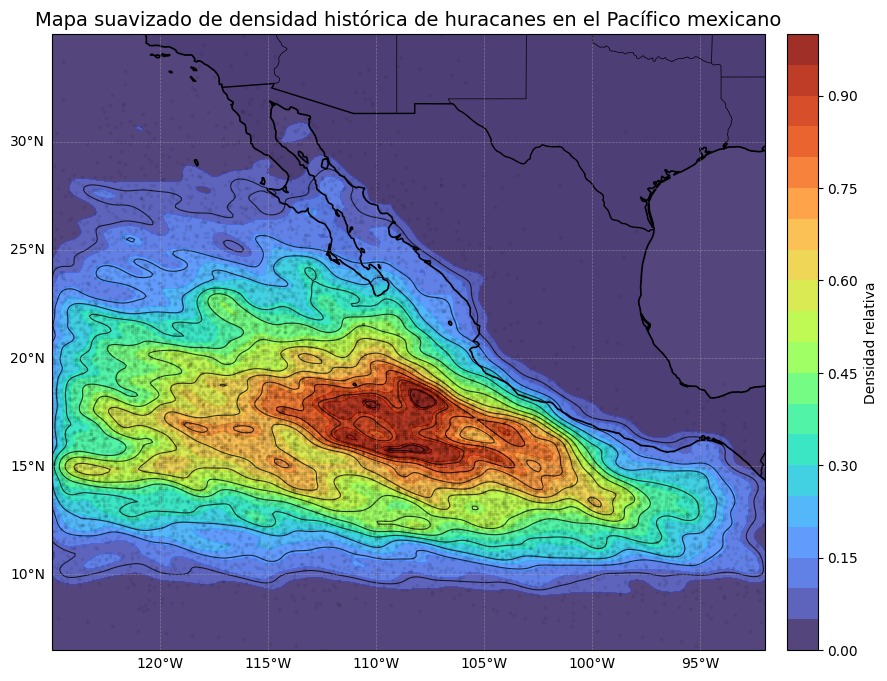

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Si estás en Colab y no tienes cartopy:
!pip install -q cartopy

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================================
# MAPA SUAVIZADO TIPO CAMPO/CONTORNOS DE HURACANES
# ============================================================

# ------------------------------------------------------------
# 1. Cargar datos
# ------------------------------------------------------------
df = pd.read_excel("huracanes_pacifico_recortado.xlsx")
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

df = df.dropna(subset=["lat", "lon"]).copy()

df = df[
    (df["lon"].between(-125, -92)) &
    (df["lat"].between(6.5, 35))
].copy()

print("Puntos usados:", len(df))

# ------------------------------------------------------------
# 2. Preparar malla espacial
# ------------------------------------------------------------
lon_min, lon_max = -125, -92
lat_min, lat_max = 6.5, 35

nx, ny = 250, 250
lon_grid = np.linspace(lon_min, lon_max, nx)
lat_grid = np.linspace(lat_min, lat_max, ny)
X, Y = np.meshgrid(lon_grid, lat_grid)

# ------------------------------------------------------------
# 3. KDE de densidad espacial
# ------------------------------------------------------------
coords = np.vstack([df["lon"].values, df["lat"].values])
kde = gaussian_kde(coords, bw_method=0.08)

grid_coords = np.vstack([X.ravel(), Y.ravel()])
Z = kde(grid_coords).reshape(X.shape)

Z = (Z - Z.min()) / (Z.max() - Z.min())

# ------------------------------------------------------------
# 4. Graficar mapa base con Cartopy
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent(
    [lon_min, lon_max, lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

# Tierra y océano
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", linewidth=0.8)
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=1.2)
ax.add_feature(cfeature.BORDERS, linewidth=1.0)

# Estados/provincias
states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="50m",
    facecolor="none"
)

ax.add_feature(states, edgecolor="black", linewidth=0.5)

# ------------------------------------------------------------
# 5. Campo suavizado y contornos
# ------------------------------------------------------------
cont = ax.contourf(
    X,
    Y,
    Z,
    levels=20,
    cmap="turbo",
    alpha=0.85,
    transform=ccrs.PlateCarree()
)

ax.contour(
    X,
    Y,
    Z,
    levels=12,
    colors="black",
    linewidths=0.8,
    alpha=0.75,
    transform=ccrs.PlateCarree()
)

# Puntos históricos opcionales
ax.scatter(
    df["lon"],
    df["lat"],
    s=3,
    alpha=0.05,
    color="black",
    transform=ccrs.PlateCarree()
)

# Grid
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    alpha=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

plt.colorbar(
    cont,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    label="Densidad relativa"
)

plt.title(
    "Mapa suavizado de densidad histórica de huracanes en el Pacífico mexicano",
    fontsize=14
)

plt.savefig(
    "mapa_densidad_huracanes_pacifico.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()